Install & check GPU

In [ ]:
!pip install -U timm torch torchvision opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 105.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.2/287.2 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

CUDA available: True
GPU: Tesla T4


Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Load DINOv2 backbone

In [ ]:
import timm
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

backbone = timm.create_model(
    "vit_base_patch14_dinov2",
    pretrained=True,
    num_classes=0   # remove classification head
).to(device)

backbone.eval()

# Freeze backbone
for p in backbone.parameters():
    p.requires_grad = False

print("Feature dimension:", backbone.num_features)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Feature dimension: 768


Dataset & DataLoader

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((518, 518)),   # 🔴 IMPORTANT
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_ds = datasets.ImageFolder(
    "/content/drive/MyDrive/TextureRecognition/dataset/train",
    transform=transform
)

val_ds = datasets.ImageFolder(
    "/content/drive/MyDrive/TextureRecognition/dataset/valid",
    transform=transform
)

train_loader = DataLoader(
    train_ds,
    batch_size=8,        # 🔴 REDUCED
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Classes:", train_ds.classes)

Classes: ['Glass', 'Metal', 'Plastic', 'Rubber']


Classifier Head

In [ ]:
import torch.nn as nn

NUM_CLASSES = len(train_ds.classes)

classifier = nn.Sequential(
    nn.Linear(backbone.num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, NUM_CLASSES)
).to(device)

Loss & Optimizer

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier.parameters(), lr=1e-3)

Training Loop (with progress prints)

In [ ]:
import time

EPOCHS = 10

for epoch in range(EPOCHS):
    print(f"\n🚀 Epoch {epoch+1} STARTED")
    start_time = time.time()

    classifier.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, (imgs, labels) in enumerate(train_loader):
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Feature extraction
        with torch.no_grad():
            features = backbone(imgs)

        outputs = classifier(features)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # 🔹 Batch progress print
        if batch_idx % 5 == 0:
            print(f"  Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

    acc = 100 * correct / total
    elapsed = time.time() - start_time

    print(f"✅ Epoch {epoch+1} DONE | Loss: {total_loss:.3f} | Acc: {acc:.2f}% | Time: {elapsed:.1f}s")


🚀 Epoch 1 STARTED
  Batch 0/587 | Loss: 1.3532
  Batch 5/587 | Loss: 0.4376
  Batch 10/587 | Loss: 0.8077
  Batch 15/587 | Loss: 0.3398
  Batch 20/587 | Loss: 0.0086
  Batch 25/587 | Loss: 0.2383
  Batch 30/587 | Loss: 0.4427
  Batch 35/587 | Loss: 0.0640
  Batch 40/587 | Loss: 0.1558
  Batch 45/587 | Loss: 0.3563
  Batch 50/587 | Loss: 0.4064
  Batch 55/587 | Loss: 0.2722
  Batch 60/587 | Loss: 0.1144
  Batch 65/587 | Loss: 0.0700
  Batch 70/587 | Loss: 0.0023
  Batch 75/587 | Loss: 0.0017
  Batch 80/587 | Loss: 0.0023
  Batch 85/587 | Loss: 0.2596
  Batch 90/587 | Loss: 0.0044
  Batch 95/587 | Loss: 0.0294
  Batch 100/587 | Loss: 0.0336
  Batch 105/587 | Loss: 0.0049
  Batch 110/587 | Loss: 0.0745
  Batch 115/587 | Loss: 0.0207
  Batch 120/587 | Loss: 0.0079
  Batch 125/587 | Loss: 0.2494
  Batch 130/587 | Loss: 0.1569
  Batch 135/587 | Loss: 0.1476
  Batch 140/587 | Loss: 0.1446
  Batch 145/587 | Loss: 0.0534
  Batch 150/587 | Loss: 0.7036
  Batch 155/587 | Loss: 0.3800
  Batch 160

Save the trained model

In [ ]:
torch.save({
    "backbone": "vit_base_patch14_dinov2",
    "classifier_state_dict": classifier.state_dict(),
    "classes": train_ds.classes
}, "/content/drive/MyDrive/dinov2_material_classifier.pth")

print("✅ Model saved successfully")

✅ Model saved successfully


In [ ]:
import torch
import timm
import torch.nn as nn
from torchvision import transforms
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"

# 🔹 Load checkpoint
checkpoint = torch.load(
    "/content/drive/MyDrive/dinov2_material_classifier.pth",
    map_location=device
)

class_names = checkpoint["classes"]
NUM_CLASSES = len(class_names)

# 🔹 Backbone
backbone = timm.create_model(
    "vit_base_patch14_dinov2",
    pretrained=True,
    num_classes=0
).to(device)

backbone.eval()
for p in backbone.parameters():
    p.requires_grad = False

# 🔹 Classifier
classifier = nn.Sequential(
    nn.Linear(backbone.num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, NUM_CLASSES)
).to(device)

classifier.load_state_dict(checkpoint["classifier_state_dict"])
classifier.eval()

print("✅ Model loaded")
print("Classes:", class_names)


✅ Model loaded
Classes: ['Glass', 'Metal', 'Plastic', 'Rubber']


In [ ]:
def predict_image(img_path):
    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        feat = backbone(x)
        out = classifier(feat)
        probs = torch.softmax(out, dim=1)

    pred_idx = probs.argmax(1).item()
    confidence = probs[0, pred_idx].item()

    print(f"🧠 Prediction: {class_names[pred_idx]}")
    print(f"📊 Confidence: {confidence*100:.2f}%")

    return class_names[pred_idx], confidence


In [ ]:
predict_image("/content/WIN_20260104_16_57_12_Pro.jpg")

🧠 Prediction: Metal
📊 Confidence: 100.00%


('Metal', 0.9999737739562988)

In [ ]:
predict_image("/content/WIN_20260104_16_56_18_Pro.jpg")

🧠 Prediction: Rubber
📊 Confidence: 89.08%


('Rubber', 0.8908166885375977)

In [ ]:
def predict_with_unknown(img_path, threshold=0.6):
    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        feat = backbone(x)
        out = classifier(feat)
        probs = torch.softmax(out, dim=1)

    conf, idx = probs.max(1)
    conf = conf.item()

    if conf < threshold:
        print("⚠️ Prediction: UNKNOWN")
        return "UNKNOWN", conf

    print(f"🧠 Prediction: {class_names[idx.item()]}")
    print(f"📊 Confidence: {conf*100:.2f}%")
    return class_names[idx.item()], conf


In [ ]:
predict_with_unknown("/content/WIN_20260104_16_56_18_Pro.jpg")

🧠 Prediction: Rubber
📊 Confidence: 89.08%


('Rubber', 0.8908166885375977)

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

def predict_with_unknown(img_path, threshold=0.6):
    img = Image.open(img_path).convert("RGB")

    # 🔹 Display image
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")

    x = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        feat = backbone(x)
        out = classifier(feat)
        probs = torch.softmax(out, dim=1)

    conf, idx = probs.max(1)
    conf = conf.item()

    if conf < threshold:
        title = f"UNKNOWN ({conf*100:.2f}%)"
        plt.title(title, color="red")
        plt.show()
        print("⚠️ Prediction: UNKNOWN")
        return "UNKNOWN", conf

    label = class_names[idx.item()]
    title = f"{label} ({conf*100:.2f}%)"
    plt.title(title, color="green")
    plt.show()

    print(f"🧠 Prediction: {label}")
    print(f"📊 Confidence: {conf*100:.2f}%")

    return label, conf


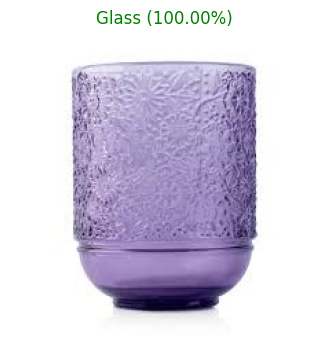

🧠 Prediction: Glass
📊 Confidence: 100.00%


('Glass', 1.0)

In [ ]:
predict_with_unknown("/content/sample 2.jpg")

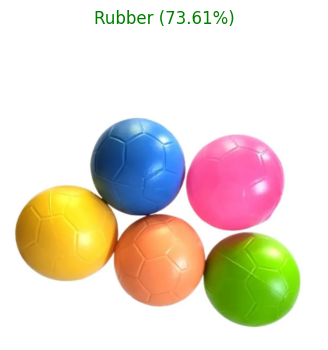

🧠 Prediction: Rubber
📊 Confidence: 73.61%


('Rubber', 0.7361411452293396)

In [ ]:
predict_with_unknown("/content/sample 6.jpg")

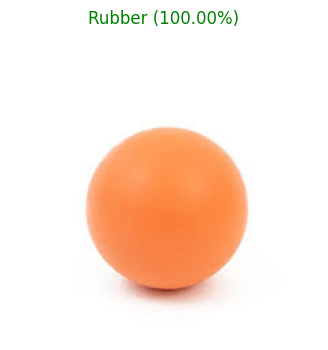

🧠 Prediction: Rubber
📊 Confidence: 100.00%


('Rubber', 0.9999998807907104)

In [ ]:
predict_with_unknown("/content/sample 5.jpg")

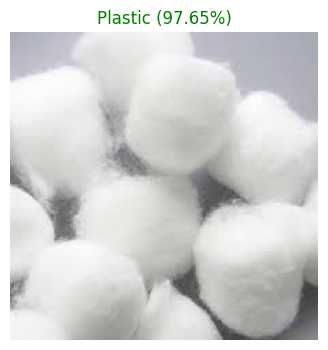

🧠 Prediction: Plastic
📊 Confidence: 97.65%


('Plastic', 0.9765465259552002)

In [ ]:
predict_with_unknown("/content/sample 7.jpg")

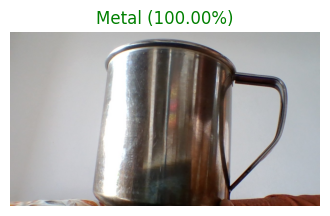

🧠 Prediction: Metal
📊 Confidence: 100.00%


('Metal', 0.9999737739562988)

In [ ]:
predict_with_unknown("/content/WIN_20260104_16_57_12_Pro.jpg")

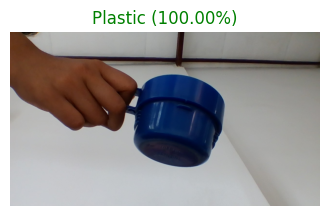

🧠 Prediction: Plastic
📊 Confidence: 100.00%


('Plastic', 1.0)

In [ ]:
predict_with_unknown("/content/WIN_20260104_16_56_26_Pro.jpg")

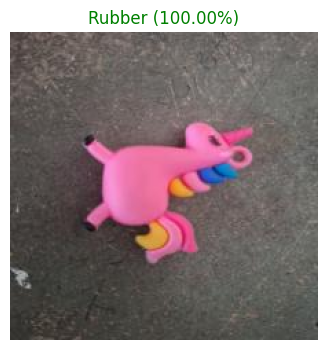

🧠 Prediction: Rubber
📊 Confidence: 100.00%


('Rubber', 1.0)

In [ ]:
predict_with_unknown("/content/Toys50_jpeg.rf.fb8c83c230eee1fd739f84f76aed03f7.jpg")

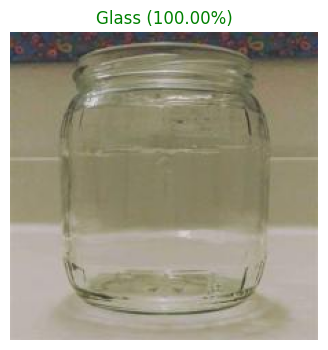

🧠 Prediction: Glass
📊 Confidence: 100.00%


('Glass', 1.0)

In [ ]:
predict_with_unknown("/content/glass_527_jpg.rf.efbd5f2d80a7b6b10a2938f7b714b25d.jpg")

In [ ]:
pip install torch torchvision timm scikit-learn matplotlib

In [ ]:
# import torch
# from torch.utils.data import DataLoader
# from torchvision import datasets, transforms
# import torch.nn as nn
# from sklearn.metrics import confusion_matrix, classification_report
# import matplotlib.pyplot as plt
# import seaborn as sns

# # ===============================
# # CONFIG
# # ===============================
# device = "cuda" if torch.cuda.is_available() else "cpu"

# # Set your dataset path here
# TEST_DIR = "/content/drive/MyDrive/TextureRecognition/dataset/test"

# IMG_SIZE = (518, 518)  # DINOv2 expects 518x518

# BATCH_SIZE = 8

# # ===============================
# # TRANSFORMS
# # ===============================
# transform = transforms.Compose([
#     transforms.Resize(IMG_SIZE),
#     transforms.ToTensor(),
#     transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     )
# ])

# # ===============================
# # DATASET & DATALOADER
# # ===============================
# test_dataset = datasets.ImageFolder(TEST_DIR, transform=transform)
# test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# class_names = test_dataset.classes
# print("Classes:", class_names)

# # ===============================
# # LOAD MODEL
# # ===============================
# # backbone + classifier should already be defined
# backbone.eval()
# classifier.eval()

# # ===============================
# # EVALUATION
# # ===============================
# all_preds = []
# all_labels = []

# correct = 0
# total = 0

# with torch.no_grad():
#     for imgs, labels in test_loader:
#         imgs, labels = imgs.to(device), labels.to(device)

#         features = backbone(imgs)
#         outputs = classifier(features)

#         _, preds = torch.max(outputs, 1)

#         all_preds.extend(preds.cpu().numpy())
#         all_labels.extend(labels.cpu().numpy())

#         correct += (preds == labels).sum().item()
#         total += labels.size(0)

# accuracy = 100 * correct / total
# print(f"✅ Test Accuracy: {accuracy:.2f}%")

# # ===============================
# # CONFUSION MATRIX
# # ===============================
# cm = confusion_matrix(all_labels, all_preds)
# plt.figure(figsize=(6,5))
# sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
# plt.xlabel("Predicted")
# plt.ylabel("True")
# plt.title("Confusion Matrix")
# plt.show()

# # ===============================
# # CLASSIFICATION REPORT
# # ===============================
# report = classification_report(all_labels, all_preds, target_names=class_names)
# print("\nClassification Report:\n")
# print(report)


Classes: ['Glass', 'Metal', 'Plastic', 'Rubber']


KeyboardInterrupt: 

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.nn as nn
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ===============================
# CONFIG
# ===============================
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# Set your dataset path here
TEST_DIR = "/content/drive/MyDrive/TextureRecognition/dataset/test"

In [ ]:
# ===============================
# DATASET & DATALOADER
# ===============================
test_dataset = datasets.ImageFolder(TEST_DIR, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = test_dataset.classes
print("Classes:", class_names)

Classes: ['Glass', 'Metal', 'Plastic', 'Rubber']


In [ ]:
# ===============================
# LOAD MODEL
# ===============================
# backbone + classifier should already be defined
backbone.eval()
classifier.eval()

In [ ]:
# ===============================
# EVALUATION
# ===============================
all_preds = []
all_labels = []

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        features = backbone(imgs)
        outputs = classifier(features)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"✅ Test Accuracy: {accuracy:.2f}%")

✅ Test Accuracy: 97.76%


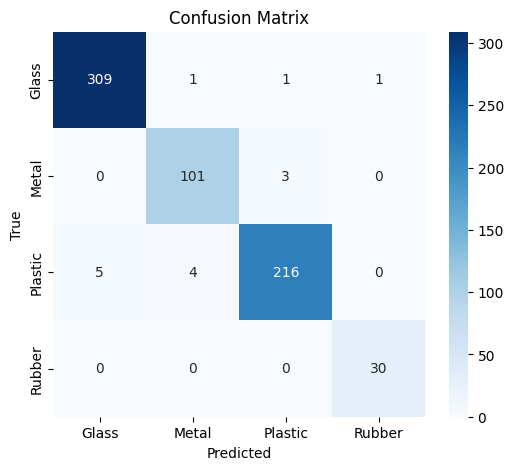

In [ ]:
# ===============================
# CONFUSION MATRIX
# ===============================
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# ===============================
# CLASSIFICATION REPORT
# ===============================
report = classification_report(all_labels, all_preds, target_names=class_names)
print("\nClassification Report:\n")
print(report)


Classification Report:

              precision    recall  f1-score   support

       Glass       0.98      0.99      0.99       312
       Metal       0.95      0.97      0.96       104
     Plastic       0.98      0.96      0.97       225
      Rubber       0.97      1.00      0.98        30

    accuracy                           0.98       671
   macro avg       0.97      0.98      0.98       671
weighted avg       0.98      0.98      0.98       671

